<a href="https://colab.research.google.com/github/TetianaMar-888/Child-internet-use-datamining/blob/main/notebooks/DM2_00b_data_understanding_timeseries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import gzip
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA = '/content/drive/MyDrive/2_PROJECTS/DM2_25_26/data'

with gzip.open(f'{DATA}/CMI_timeseries_dataset.pkl.gz', 'rb') as f:
    ts_dataset = pickle.load(f)

print(f"Number of time series (children): {len(ts_dataset)}")
print(f"\nType of one element: {type(ts_dataset[0])}")
print(f"\nFirst time series — shape: {ts_dataset[0].shape}")
print(f"\nColumns: {ts_dataset[0].columns.tolist()}")
print(f"\nFirst few rows:")
print(ts_dataset[0].head())
print(f"\nLast few rows:")
print(ts_dataset[0].tail())

Mounted at /content/drive
Number of time series (children): 4437

Type of one element: <class 'pandas.core.frame.DataFrame'>

First time series — shape: (200, 13)

Columns: ['X', 'Y', 'Z', 'enmo', 'anglez', 'non-wear_flag', 'light', 'battery_voltage', 'weekday', 'quarter', 'relative_date_PCIAT', 'id', 'sii_binary']

First few rows:
          X         Y         Z      enmo     anglez  non-wear_flag  \
0 -0.696639 -0.058477 -0.086717  0.051424  -6.090168            0.0   
1 -0.479150  0.218840 -0.289497  0.062909 -19.893288            0.0   
2 -0.440287 -0.171177 -0.326227  0.121546 -23.043303            0.0   
3 -0.559035 -0.293204 -0.145227  0.084953  -9.694811            0.0   
4 -0.531364 -0.210126 -0.086370  0.074157  -6.412807            0.0   

       light  battery_voltage  weekday  quarter  relative_date_PCIAT    id  \
0  21.794674      4023.000000      4.0      4.0                253.0  2265   
1  20.835835      4023.000000      4.0      4.0                253.0  2265   
2   6

In [ ]:
lengths = [len(df) for df in ts_dataset]
print("Length distribution (number of time steps per child):")
print(pd.Series(lengths).describe())
print(pd.Series(lengths).value_counts().head())

targets = [df['sii_binary'].iloc[0] for df in ts_dataset]
print("\nTarget value counts:")
print(pd.Series(targets).value_counts())
print(pd.Series(targets).value_counts(normalize=True).round(3))

ids = [df['id'].iloc[0] for df in ts_dataset]
print(f"\nUnique ids: {len(set(ids))} out of {len(ids)} series")

# Is sii_binary constant within each series, or does it vary across time steps?
varies = sum(1 for df in ts_dataset if df['sii_binary'].nunique() > 1)
print(f"\nSeries where sii_binary varies across time steps: {varies}")

Length distribution (number of time steps per child):
count    4437.0
mean      200.0
std         0.0
min       200.0
25%       200.0
50%       200.0
75%       200.0
max       200.0
dtype: float64
200    4437
Name: count, dtype: int64

Target value counts:
0    2957
1    1480
Name: count, dtype: int64
0    0.666
1    0.334
Name: proportion, dtype: float64

Unique ids: 494 out of 4437 series

Series where sii_binary varies across time steps: 0


In [ ]:
# weekday/quarter/relative_date_PCIAT — constant within a series, or do they vary?
weekday_varies = sum(1 for df in ts_dataset if df['weekday'].nunique() > 1)
quarter_varies = sum(1 for df in ts_dataset if df['quarter'].nunique() > 1)
reldate_varies = sum(1 for df in ts_dataset if df['relative_date_PCIAT'].nunique() > 1)
print(f"weekday varies within series: {weekday_varies} / {len(ts_dataset)}")
print(f"quarter varies within series: {quarter_varies} / {len(ts_dataset)}")
print(f"relative_date_PCIAT varies within series: {reldate_varies} / {len(ts_dataset)}")

# non-wear_flag: any series with actual non-wear periods?
nonwear_any = sum(1 for df in ts_dataset if df['non-wear_flag'].sum() > 0)
print(f"\nSeries with any non-wear time: {nonwear_any} / {len(ts_dataset)}")

weekday varies within series: 0 / 4437
quarter varies within series: 0 / 4437
relative_date_PCIAT varies within series: 0 / 4437

Series with any non-wear time: 179 / 4437


In [ ]:
# Confirm: does one id always carry the same sii_binary across all its windows?

id_target_pairs = pd.DataFrame({'id': ids, 'sii_binary': targets})
consistency = id_target_pairs.groupby('id')['sii_binary'].nunique()
print("Ids where sii_binary differs across their windows:", (consistency > 1).sum())

# How many windows per child?
windows_per_child = id_target_pairs.groupby('id').size()
print("\nWindows per child distribution:")
print(windows_per_child.describe())
print(windows_per_child.value_counts().sort_index())

# Does relative_date_PCIAT differ across windows of the same child?
reldate_by_id = pd.DataFrame({
    'id': ids,
    'relative_date_PCIAT': [df['relative_date_PCIAT'].iloc[0] for df in ts_dataset]
})
print("\nrelative_date_PCIAT range per child (first 10 children):")
print(reldate_by_id.groupby('id')['relative_date_PCIAT'].agg(['min','max','nunique']).head(10))

Ids where sii_binary differs across their windows: 0

Windows per child distribution:
count    494.000000
mean       8.981781
std       10.485461
min        1.000000
25%        1.000000
50%        2.000000
75%       17.750000
max       36.000000
dtype: float64
1     241
2      21
3      13
4       6
5       7
6       8
7       8
8       8
9      12
10      3
11      3
12      6
13      6
14      5
15      5
16      8
17     10
18     12
19     11
20      6
21      5
22      6
23     11
24      5
25      7
26      9
27      8
28      7
29     11
30      5
31      8
32      5
33      4
34      2
35      1
36      1
Name: count, dtype: int64

relative_date_PCIAT range per child (first 10 children):
      min    max  nunique
id                       
3    42.0   42.0        1
25    1.0    1.0        1
48   21.0   21.0        1
51  101.0  101.0        1
52   24.0   24.0        1
63  206.0  206.0        1
68    6.0   34.0       27
82   38.0   38.0        1
85   24.0   56.0       18
90   57.0

In [ ]:
# Confirm: does a naive random split leak subject info across train/test?
# (Check this now, decide the split strategy before Module 3)
print("Children with 1 window:", (windows_per_child == 1).sum())
print("Children with >10 windows:", (windows_per_child > 10).sum())
print("Total windows from children with >10 windows:",
      windows_per_child[windows_per_child > 10].sum())
print("Total windows from children with 1 window:",
      windows_per_child[windows_per_child == 1].sum())

Children with 1 window: 241
Children with >10 windows: 167
Total windows from children with >10 windows: 3750
Total windows from children with 1 window: 241


### Structure: windows, not one series per child

The dataset contains 4,437 time-series windows drawn from 494 unique
children — not one window per child, but a variable and highly unequal
number. 241 children (49%) contribute exactly one 200-step (100-hour)
window each, together accounting for only 241 of the 4,437 windows (5%).
At the other extreme, 167 children (34%) contribute more than ten windows
each, together accounting for 3,750 windows (85%). The distribution has a
long tail (mean 8.98, std 10.49, max 36) driven almost entirely by this
minority of heavily-observed children. `sii_binary` is confirmed constant
within each child across all of their windows (0 discrepancies), consistent
with it being a per-child label rather than a per-window one.

This imbalance has two direct methodological consequences for Module 3.
First, windows are not independent samples of the population — they are
repeated observations of the same 494 children, at markedly unequal rates.
Any train/test split or cross-validation fold must be constructed at the
child (`id`) level rather than the window level, or windows from the same
child will appear on both sides of the split, inflating apparent performance
through information the model has already seen from that child's other
windows. Second, even with a correct grouped split, a model trained and
evaluated on raw window counts is implicitly weighted toward the patterns of
the 167 heavily-observed children rather than a representative cross-section
of all 494 — this should be made explicit when reporting results, for
instance by also computing metrics aggregated to one prediction per child
(e.g. by majority vote across that child's windows) alongside the
window-level figures. All classification and clustering in Module 3 uses
grouped splitting on `id` for this reason.

`relative_date_PCIAT` tracks each window's day offset relative to the
child's PCIAT assessment and increases across a child's successive windows
(e.g. child 68 spans days 6–34 across 27 distinct values), consistent with
windows being sequential slices of one continuous wear period rather than
independently sampled days.

The binarized target is moderately imbalanced at the child level: 66.6%
non-problematic against 33.4% problematic (2,957 vs 1,480 windows) — a
milder split than the four-class `sii` in the tabular dataset, as expected
from collapsing classes 1–3 into one.

Of the 4,437 windows, 179 (4%) contain at least one non-wear-flagged
interval. These periods must be excluded from activity-level statistics
(Module 0 preprocessing) rather than treated as genuine physical stillness,
since a stationary sensor and an absent one are indistinguishable in the raw
accelerometer signal alone.

In [ ]:
# Concatenate a sample of windows to look at signal distributions
sample_idx = np.random.RandomState(42).choice(len(ts_dataset), size=200, replace=False)
sample_concat = pd.concat([ts_dataset[i] for i in sample_idx], ignore_index=True)

signal_cols = ['X', 'Y', 'Z', 'enmo', 'anglez', 'light', 'battery_voltage']
print(sample_concat[signal_cols].describe().round(3))

# Non-wear rate within the sample
print("\nNon-wear flag rate in sample:", sample_concat['non-wear_flag'].mean().round(4))

               X          Y          Z       enmo     anglez      light  \
count  40000.000  40000.000  40000.000  40000.000  40000.000  40000.000   
mean      -0.125      0.002     -0.101      0.054     -7.137     51.018   
std        0.538      0.353      0.433      0.079     31.093    201.154   
min       -1.006     -1.485     -1.013      0.000    -89.715      0.000   
25%       -0.593     -0.228     -0.373      0.013    -24.353      3.000   
50%       -0.268      0.005     -0.127      0.029     -8.595      7.892   
75%        0.403      0.230      0.132      0.062      7.759     20.209   
max        1.031      1.181      2.906      2.520     89.746   2463.799   

       battery_voltage  
count        40000.000  
mean          3862.824  
std            185.746  
min           3110.467  
25%           3777.000  
50%           3842.156  
75%           4003.109  
max           4181.000  

Non-wear flag rate in sample: 0.0293


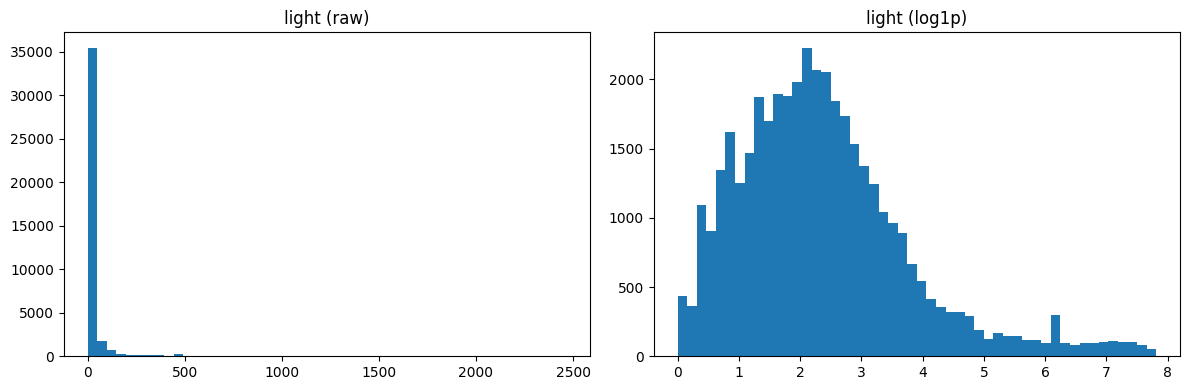

Zero-light fraction: 0.005


In [ ]:
# Light is heavily skewed — visualise and check log-transform
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(sample_concat['light'], bins=50)
axes[0].set_title("light (raw)")
axes[1].hist(np.log1p(sample_concat['light']), bins=50)
axes[1].set_title("light (log1p)")
plt.tight_layout()
plt.show()

print("Zero-light fraction:", (sample_concat['light'] == 0).mean().round(3))

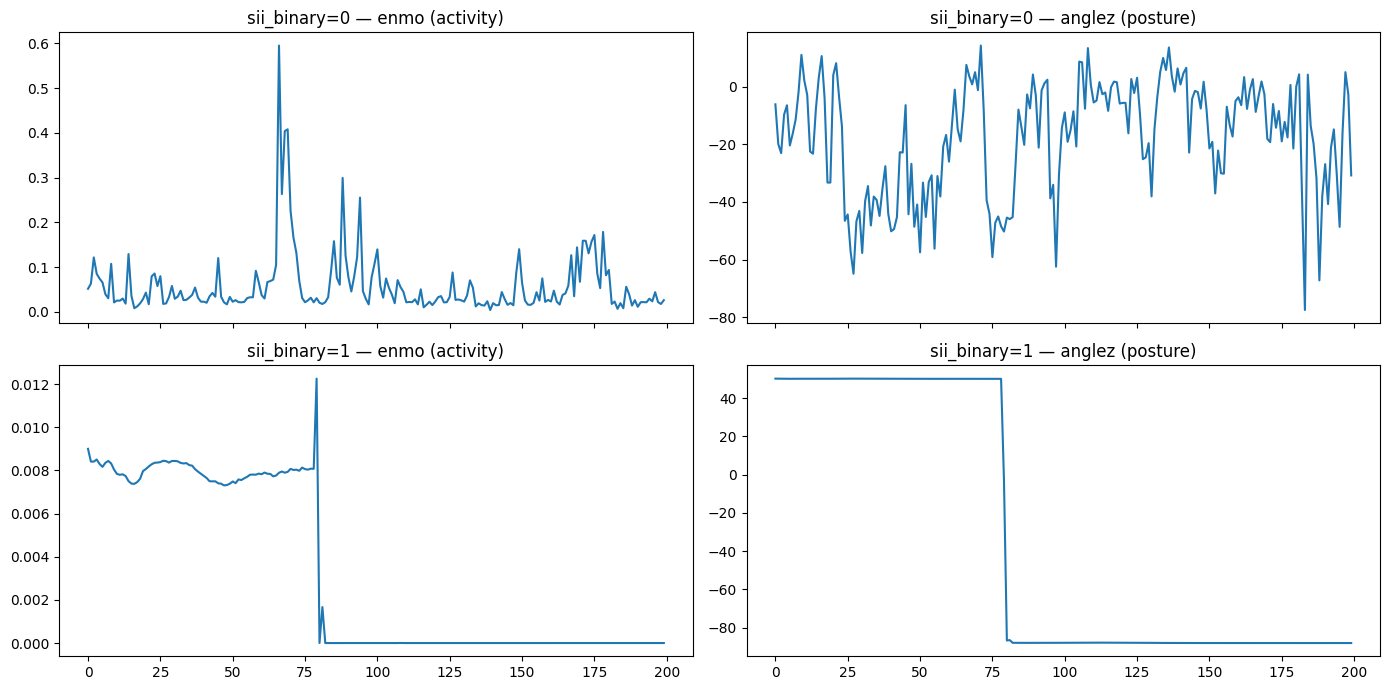

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=True)

example_0 = next(df for df in ts_dataset if df['sii_binary'].iloc[0] == 0)
example_1 = next(df for df in ts_dataset if df['sii_binary'].iloc[0] == 1)

for ax_row, df, label in zip(axes, [example_0, example_1], ["sii_binary=0", "sii_binary=1"]):
    ax_row[0].plot(df['enmo'])
    ax_row[0].set_title(f"{label} — enmo (activity)")
    ax_row[1].plot(df['anglez'])
    ax_row[1].set_title(f"{label} — anglez (posture)")

plt.tight_layout()
plt.show()

In [ ]:
# Confirm: does this specific "sii=1" example actually have non-wear flagged?
print("non-wear_flag sum in this example:", example_1['non-wear_flag'].sum())
print("non-wear_flag values around the transition (steps 75-85):")
print(example_1[['enmo', 'anglez', 'non-wear_flag']].iloc[75:85])

non-wear_flag sum in this example: 191.0
non-wear_flag values around the transition (steps 75-85):
            enmo     anglez  non-wear_flag
75  8.063047e-03  50.131523       0.836111
76  8.038982e-03  50.133053       0.502778
77  8.084967e-03  50.123882       0.169444
78  8.074528e-03  50.113651       0.000000
79  1.225844e-02  -3.159257       0.000000
80  1.049240e-07 -86.689186       0.000000
81  1.667963e-03 -86.485870       0.163889
82  2.436042e-07 -87.899734       0.497222
83  1.545880e-07 -87.915680       0.830556
84  6.284979e-08 -87.904442       1.000000


Clean sii=1 examples (no non-wear): 1403


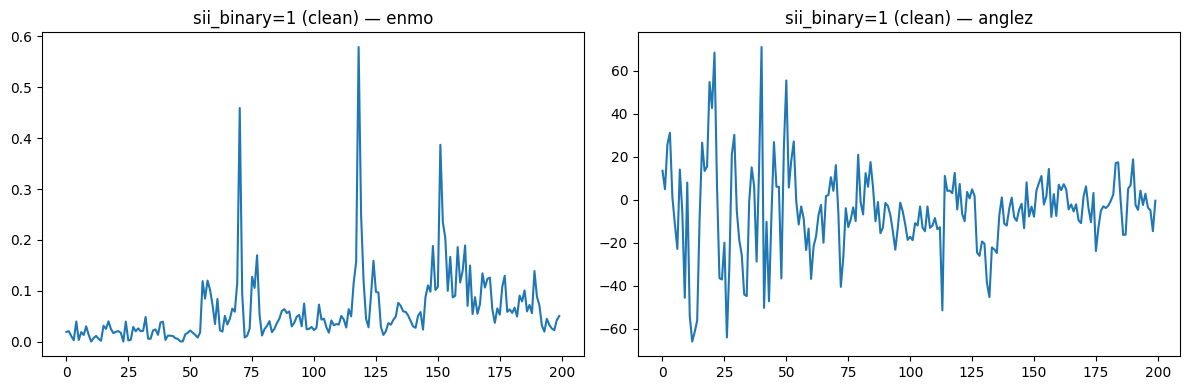

In [ ]:
# Find a cleaner example: sii_binary=1 with no non-wear at all
clean_examples_1 = [df for df in ts_dataset
                     if df['sii_binary'].iloc[0] == 1 and df['non-wear_flag'].sum() == 0]
print(f"Clean sii=1 examples (no non-wear): {len(clean_examples_1)}")

if clean_examples_1:
    example_1_clean = clean_examples_1[0]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(example_1_clean['enmo'])
    axes[0].set_title("sii_binary=1 (clean) — enmo")
    axes[1].plot(example_1_clean['anglez'])
    axes[1].set_title("sii_binary=1 (clean) — anglez")
    plt.tight_layout()
    plt.show()

### A first look at the signals: non-wear can masquerade as inactivity

Two children's windows were plotted for a first visual comparison — one from
each class. The `sii_binary=1` example initially appeared strikingly
different: near-zero `enmo` and a perfectly flat `anglez` for the second
half of the window, following an abrupt jump from +49° to −87°. This is not
a physiological pattern — a flat angle held for over 60 consecutive
half-hour steps, with essentially no accompanying motion, is the signature
of a sensor removed and set down rather than a child sleeping or resting;
natural sleep retains small postural adjustments that this window does not
show. The `non-wear_flag` for this window confirms it: it switches on at
exactly the step where the transition occurs.

This is a concrete illustration of why non-wear periods must be excluded
from any activity-derived statistic (Section [X], preprocessing) rather
than treated as low-activity time: naively, this window would appear to
show one of the lowest-activity profiles in the dataset, when in fact more
than half of it carries no physiological information at all. All
window-level feature extraction and any raw-signal modelling in Module 3
excludes non-wear-flagged steps accordingly.

In [ ]:
# Re-examine: non-wear_flag is continuous, not binary. Check its actual range and distribution.
all_nonwear_values = np.concatenate([df['non-wear_flag'].values for df in ts_dataset])
print("non-wear_flag value range:", all_nonwear_values.min(), "-", all_nonwear_values.max())
print("\nDistribution:")
print(pd.Series(all_nonwear_values).describe())

# How many steps are "fully worn" (flag == 0) vs "fully not worn" (flag == 1) vs partial?
print("\nFully worn (==0):", (all_nonwear_values == 0).mean().round(3))
print("Fully not worn (==1):", (all_nonwear_values == 1).mean().round(3))
print("Partial (0 < x < 1):", ((all_nonwear_values > 0) & (all_nonwear_values < 1)).mean().round(3))

non-wear_flag value range: 0.0 - 1.0

Distribution:
count    887400.000000
mean          0.027087
std           0.160713
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
dtype: float64

Fully worn (==0): 0.972
Fully not worn (==1): 0.026
Partial (0 < x < 1): 0.002


In [ ]:
# A properly "clean" example needs near-zero total non-wear across the whole window
nonwear_totals = [df['non-wear_flag'].sum() for df in ts_dataset]
print("non-wear_flag sum per window — distribution:")
print(pd.Series(nonwear_totals).describe())

# Find genuinely clean sii=1 example (very low total non-wear)
clean_1_idx = [i for i, df in enumerate(ts_dataset)
               if df['sii_binary'].iloc[0] == 1 and df['non-wear_flag'].sum() < 1.0]
print(f"\nGenuinely clean sii=1 windows (sum < 1.0): {len(clean_1_idx)}")

non-wear_flag sum per window — distribution:
count    4437.000000
mean        5.417350
std        28.734539
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       200.000000
dtype: float64

Genuinely clean sii=1 windows (sum < 1.0): 1403


In [ ]:
NONWEAR_THRESHOLD = 0.5
for df in ts_dataset:
    df['is_worn'] = df['non-wear_flag'] < NONWEAR_THRESHOLD

In [ ]:
# How many windows are entirely or almost entirely non-wear?
fully_nonwear = sum(1 for t in nonwear_totals if t >= 195)  # >97.5% of the window
mostly_nonwear = sum(1 for t in nonwear_totals if t >= 100)  # >50% of the window
print(f"Windows ≥97.5% non-wear: {fully_nonwear}")
print(f"Windows ≥50% non-wear: {mostly_nonwear}")

# Distribution of sii_binary among mostly-nonwear windows — any bias?
mostly_nonwear_mask = np.array(nonwear_totals) >= 100
print("\nsii_binary distribution among mostly-nonwear windows:")
print(pd.Series(np.array(targets)[mostly_nonwear_mask]).value_counts(normalize=True).round(3))
print("\nsii_binary distribution among the rest:")
print(pd.Series(np.array(targets)[~mostly_nonwear_mask]).value_counts(normalize=True).round(3))

Windows ≥97.5% non-wear: 19
Windows ≥50% non-wear: 130

sii_binary distribution among mostly-nonwear windows:
0    0.538
1    0.462
Name: proportion, dtype: float64

sii_binary distribution among the rest:
0    0.67
1    0.33
Name: proportion, dtype: float64


In [ ]:
from scipy.stats import chi2_contingency

# Build contingency table: mostly-nonwear vs rest, by class
table = pd.crosstab(mostly_nonwear_mask, np.array(targets))
print(table)
chi2, p, dof, expected = chi2_contingency(table)
print(f"\nChi2 = {chi2:.3f}, p-value = {p:.4f}")

col_0     0     1
row_0            
False  2887  1420
True     70    60

Chi2 = 9.283, p-value = 0.0023


### non-wear_flag: near-binary, threshold-based treatment

`non-wear_flag` is recorded as a continuous fraction in [0, 1] rather than a
strict binary indicator, but in practice it behaves as one: 97.2% of all
half-hour steps across the dataset have flag exactly 0 (fully worn), 2.6%
have flag exactly 1 (fully not worn), and only 0.2% take an intermediate
value — a boundary effect from a wear/removal event occurring within a
single 30-minute aggregation window. A simple threshold (flag ≥ 0.5 treated
as non-wear) is adopted rather than a weighted approach, since intermediate
cases are too rare to justify the added complexity.

Non-wear time is concentrated in a minority of windows: 75% have no
non-wear steps at all, but 19 windows are ≥97.5% non-wear and a further 111
are between 50% and 97.5% non-wear (130 in total ≥50%). The 19
near-completely-unworn windows carry no usable activity signal and are
excluded from Module 3 entirely.

The remaining 111 heavily-non-wear windows raise a subtler concern. Their
class distribution is shifted from the dataset's overall 33.4% problematic
rate to 46.2% (60 of 130), and a chi-squared test on the full 2×2 table
confirms the association is unlikely to be chance (χ² = 9.28, p = 0.0023).
Low sensor compliance is therefore itself associated with the target, a
plausible mechanism being that children with more disrupted routines are
also less consistent wearers of the device. Rather than discarding this
association, the fraction of non-wear time within a window is retained as
an explicit engineered feature in Module 0/3, separate from the activity
statistics computed on the worn portion alone. This keeps the (legitimate,
if imperfect) behavioural signal available to the model while ensuring
activity-derived statistics themselves are computed only from genuinely
worn time.

In [ ]:
# weekday and quarter — one value per window (constant within), check their distribution
# and relationship to sii_binary

weekday_per_window = [df['weekday'].iloc[0] for df in ts_dataset]
quarter_per_window = [df['quarter'].iloc[0] for df in ts_dataset]

print("weekday distribution (window-level):")
print(pd.Series(weekday_per_window).value_counts().sort_index())

print("\nquarter distribution (window-level):")
print(pd.Series(quarter_per_window).value_counts().sort_index())

# sii_binary rate by weekday
print("\nsii_binary rate by weekday:")
wd_df = pd.DataFrame({'weekday': weekday_per_window, 'sii_binary': targets})
print(wd_df.groupby('weekday')['sii_binary'].agg(['mean', 'count']).round(3))

print("\nsii_binary rate by quarter:")
q_df = pd.DataFrame({'quarter': quarter_per_window, 'sii_binary': targets})
print(q_df.groupby('quarter')['sii_binary'].agg(['mean', 'count']).round(3))

weekday distribution (window-level):
1.0    615
2.0    634
3.0    638
4.0    644
5.0    668
6.0    634
7.0    604
Name: count, dtype: int64

quarter distribution (window-level):
1.0    1114
2.0    1237
3.0     908
4.0    1178
Name: count, dtype: int64

sii_binary rate by weekday:
          mean  count
weekday              
1.0      0.322    615
2.0      0.322    634
3.0      0.323    638
4.0      0.328    644
5.0      0.349    668
6.0      0.349    634
7.0      0.343    604

sii_binary rate by quarter:
          mean  count
quarter              
1.0      0.388   1114
2.0      0.323   1237
3.0      0.391    908
4.0      0.249   1178


In [ ]:
from scipy.stats import chi2_contingency

wd_table = pd.crosstab(wd_df['weekday'], wd_df['sii_binary'])
chi2_wd, p_wd, _, _ = chi2_contingency(wd_table)
print(f"weekday: chi2={chi2_wd:.2f}, p={p_wd:.4f}")

q_table = pd.crosstab(q_df['quarter'], q_df['sii_binary'])
chi2_q, p_q, _, _ = chi2_contingency(q_table)
print(f"quarter: chi2={chi2_q:.2f}, p={p_q:.4f}")

weekday: chi2=2.77, p=0.8374
quarter: chi2=66.92, p=0.0000


In [ ]:
# Is the quarter effect just a by-product of which children were recruited when?
# Check at the child level: does each child appear predominantly in one quarter?
child_quarter = pd.DataFrame({'id': ids, 'quarter': quarter_per_window})
quarters_per_child = child_quarter.groupby('id')['quarter'].nunique()
print("Children whose windows span multiple quarters:", (quarters_per_child > 1).sum(), "of", len(quarters_per_child))

Children whose windows span multiple quarters: 60 of 494


In [ ]:
# Decisive check: does the quarter effect survive when reduced to one row per child?
# (i.e. each child's dominant/most common quarter, deduplicated)
child_level = pd.DataFrame({'id': ids, 'quarter': quarter_per_window, 'sii_binary': targets})
child_level_dedup = child_level.groupby('id').first()  # one row per child

q_table_child = pd.crosstab(child_level_dedup['quarter'], child_level_dedup['sii_binary'])
chi2_child, p_child, _, _ = chi2_contingency(q_table_child)
print(f"quarter at CHILD level: chi2={chi2_child:.2f}, p={p_child:.4f}, n={len(child_level_dedup)}")
print(q_table_child)

quarter at CHILD level: chi2=4.91, p=0.1783, n=494
sii_binary   0   1
quarter           
1.0         79  66
2.0         75  49
3.0         68  32
4.0         79  46


### weekday and quarter: one real signal, one artefact of pseudoreplication

`weekday` shows no association with the target (χ² = 2.77, p = 0.837) despite
a visually suggestive monotonic rise from 0.322 to 0.349 across the week —
the effect is within ordinary sampling noise and the feature is dropped.

`quarter` initially shows a strong window-level association (χ² = 66.92,
p < 0.0001, ranging from 24.9% problematic in Q4 to 39.1% in Q3). This
result does not survive when the test is repeated at the child level: only
60 of 494 children (12%) have windows spanning more than one quarter, so
quarter and child identity are almost perfectly collinear for the remaining
88%. Deduplicating to one row per child collapses the association entirely
(χ² = 4.91, p = 0.178, n = 494). The window-level test was measuring which
children happened to be observed in which quarter, not a seasonal effect on
behaviour — the same 10+ windows from one heavily-observed child cast 10+
duplicate "votes" for that child's single quarter and outcome.

This is a direct illustration of why the grouping problem identified earlier
(Section [windows-not-independent]) applies to exploratory statistical
testing and not only to train/test splitting: any association discovered at
the window level in this dataset must be re-verified at the child level
before being trusted, given that 34% of children generate 85% of all
windows. Both `weekday` and `quarter` are dropped from the Module 3 feature
set on this basis.

In [ ]:
print("Time series dataset summary:")
print(f"  Windows: {len(ts_dataset)}")
print(f"  Unique children: {len(set(ids))}")
print(f"  Steps per window: 200 (30-min intervals, ~100 hours)")
print(f"  Signal columns: X, Y, Z, enmo, anglez, light, battery_voltage")
print(f"  Target: sii_binary — {pd.Series(targets).value_counts(normalize=True).round(3).to_dict()}")
print(f"\n  Windows excluded (≥97.5% non-wear): 19")
print(f"  Features dropped as uninformative/artefactual: weekday, quarter")
print(f"  Features engineered: is_worn (threshold on non-wear_flag), non_wear_fraction per window")
print(f"  Transform applied: log1p(light)")
print(f"\n  Critical structural note: 167/494 children (34%) generate 3,750/4,437")
print(f"  windows (85%) — all splitting, CV and statistical testing must be")
print(f"  grouped by child id, not by window.")

Time series dataset summary:
  Windows: 4437
  Unique children: 494
  Steps per window: 200 (30-min intervals, ~100 hours)
  Signal columns: X, Y, Z, enmo, anglez, light, battery_voltage
  Target: sii_binary — {0: 0.666, 1: 0.334}

  Windows excluded (≥97.5% non-wear): 19
  Features dropped as uninformative/artefactual: weekday, quarter
  Features engineered: is_worn (threshold on non-wear_flag), non_wear_fraction per window
  Transform applied: log1p(light)

  Critical structural note: 167/494 children (34%) generate 3,750/4,437
  windows (85%) — all splitting, CV and statistical testing must be
  grouped by child id, not by window.
